# 10. Sampling va Sampling Distribution

## 1. Sampling nima?

**Sampling** — bu katta dataset yoki umumiy to‘plamdan (population) uning kichik qismi (sample) ni tanlab olish jarayoni.

Mashina o‘rganishda har doim ham butun population bilan ishlashning imkoni bo‘lmaydi. Shuning uchun biz sample olamiz va shu sample orqali umumiy holat haqida xulosa qilamiz.

### Oddiy misol:

Agar sizda 1 million ta mijoz haqidagi ma’lumot bo‘lsa, hammasini tahlil qilish qiyin bo‘ladi. Shunda siz 10 000 ta mijozni tanlab, ulardan umumiy xulosa chiqarasiz.

---

## 2. Population va Sample

* **Population** — butun to‘plam
* **Sample** — population ichidan olingan kichik qism

### Misol:

* Population: barcha maktab o‘quvchilari
* Sample: faqat 100 ta o‘quvchi

Sample to‘g‘ri tanlansa, u population’ni yaxshi ifodalaydi.

---

## 3. Nega sampling kerak?

Sampling quyidagi holatlarda ishlatiladi:

* katta data bilan tezroq ishlash uchun
* vaqt va xotirani tejash uchun
* statistik xulosalar chiqarish uchun
* modelni train/test ga bo‘lish uchun
* A/B testing va survey’larda

---

## 4. Sampling turlari

### 4.1 Simple Random Sampling

Har bir element tanlanish uchun teng imkoniyatga ega bo‘ladi.

### 4.2 Stratified Sampling

Population ichidagi guruhlar saqlangan holda sample olinadi.
Masalan, erkak/ayol, sinflar, klasslar bo‘yicha balans saqlanadi.

### 4.3 Systematic Sampling

Har k ta elementdan bittasi olinadi.

### 4.4 Cluster Sampling

Population bir nechta guruhga bo‘linadi, keyin ba’zi guruhlar tanlanadi.

---

## 5. Machine Learning’da sampling

ML’da sampling juda ko‘p ishlatiladi:

* train/test split
* cross-validation
* bootstrap sampling
* imbalanced dataset’larda balanslash
* mini-batch training

Masalan, katta dataset’ni butunlay o‘qitish o‘rniga mini-batch bilan o‘qitamiz.

---


## 6. Sampling misoli: pandas bilan

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'name': ['Ali', 'Vali', 'Sardor', 'Diyor', 'Aziza', 'Malika', 'Olim', 'Nodir', 'Jamshid', 'Zarina'],
    'age': [20, 21, 22, 23, 19, 25, 24, 26, 18, 22]
})

### Random sample olish

In [2]:
sample_df = df.sample(n=4, random_state=42)
sample_df

,name,age
8,Jamshid,18
1,Vali,21
5,Malika,25
0,Ali,20


## 8. Sampling Distribution nima?

**Sampling distribution** — bu bir sample’dan emas, balki ko‘p sample’lardan olingan statistik qiymatlarning taqsimoti.

Oddiy qilib aytganda:

* bir sample’dan mean olamiz
* keyin yana boshqa sample’dan mean olamiz
* yana, yana, yana
* shu mean’larning tarqalishi sampling distribution bo‘ladi

### Muhim:

Bu yerda biz raw data’ni emas, **statistika** ni tarqatamiz.
Masalan:

* sample mean’lar taqsimoti
* sample median’lar taqsimoti
* sample proportion’lar taqsimoti

---

## 9. Sampling distribution nega muhim?

Chunki u bizga quyidagilarni tushunishga yordam beradi:

* sample mean population mean’ga qanchalik yaqin?
* natijalar qanchalik o‘zgaruvchan?
* model bahosi qanchalik ishonchli?
* confidence interval hisoblash mumkinmi?

---

## 10. Oddiy misol bilan tushunish

Tasavvur qiling, population’da 10 000 ta odam bor.
Siz har safar 100 tadan sample olasiz va ularning o‘rtacha yoshini topasiz.

Har bir sample’dan chiqqan mean boshqacha bo‘ladi.

Shu mean’larning barchasi birga olinganda, bu **sampling distribution of the mean** bo‘ladi.

---


## 11. Sampling distribution’ni kod bilan ko‘rsatish

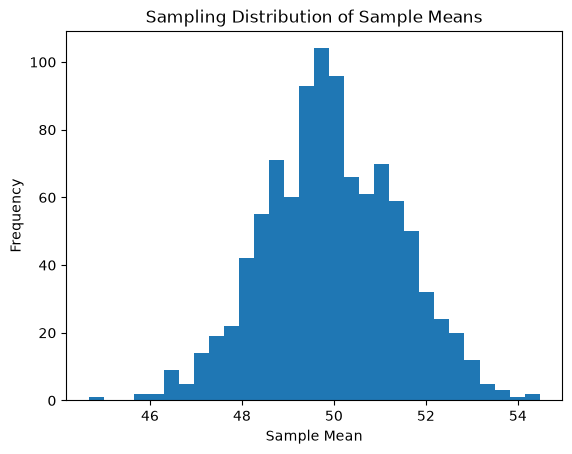

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Population yaratamiz
population = np.random.normal(loc=50, scale=10, size=10000)

# 1000 ta sample olamiz
sample_means = []

for i in range(1000):
    sample = np.random.choice(population, size=50, replace=True)
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=30)
plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()




### Izoh:

* `population` — katta to‘plam
* `sample` — kichik tanlama
* `sample_means` — har bir sample’ning o‘rtachasi

---

## 12. Sample mean nima beradi?

Agar sample soni yetarlicha katta bo‘lsa, sample mean odatda population mean’ga yaqin bo‘ladi.

Bu statistikada juda muhim g‘oya.

---

## 13. Central Limit Theorem bilan bog‘liqligi

Sampling distribution ko‘pincha **Central Limit Theorem** bilan bog‘lanadi.

Agar sample hajmi katta bo‘lsa, sample mean’larning taqsimoti odatda normal taqsimotga yaqinlashadi.

Bu ML va statistika uchun juda foydali.

---

## 14. ML’da sampling distribution misoli

Aytaylik, siz model accuracy’sini baholamoqchisiz.
Bir marta train/test split qilish yetarli emas.
Turli sample’lar bilan qayta-qayta tekshirib, accuracy’larning taqsimotini ko‘rasiz.

Bu sizga model barqarorligini ko‘rsatadi.

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

accuracies = []

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=i
    )
    
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

print("Mean accuracy:", np.mean(accuracies))
print("Std accuracy:", np.std(accuracies))

Mean accuracy: 0.9468888888888888
Std accuracy: 0.03093521705630959



```

Bu yerda biz model accuracy’larining taqsimotini ko‘rib turibmiz.
Bu ham sampling distribution’ga yaqin fikr.

---

## 15. Bootstrap sampling

**Bootstrap sampling** — replacement bilan sample olish usuli.

Bu usul:

* confidence interval
* model uncertainty
* statistik baholash
  uchun ishlatiladi.

### Misol:

```python
data = np.array([10, 20, 30, 40, 50])

bootstrap_sample = np.random.choice(data, size=5, replace=True)
bootstrap_sample
```

Agar shu jarayonni ko‘p marta takrorlasak, sample statistic’lar taqsimoti hosil bo‘ladi.

---

## 16. Sample va sampling distribution farqi

### Sample:

Population’dan olingan kichik data bo‘lagi.

### Sampling distribution:

Ko‘p sample’lardan olingan statistic’larning taqsimoti.

---

## 17. Qisqa xulosa

* **Sampling** — population’dan sample olish
* **Sample** — kichik tanlama
* **Sampling distribution** — ko‘p sample statistic’larining taqsimoti
* ML’da sampling juda muhim
* Bootstrap, train/test split, cross-validation shu tushunchalar bilan bog‘liq

---


## 19. Amaliy mashq




Quyidagi kodni yozing:

1. 1000 ta random son yarating
2. Ulardan 50 tadan sample oling
3. Har bir sample mean’ini hisoblang
4. Histogram chizing

```python

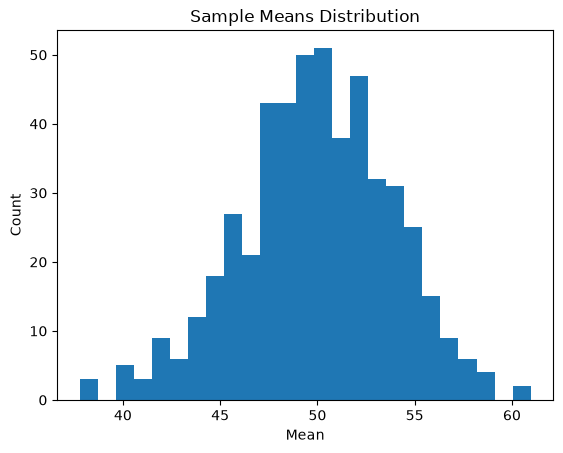

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

population = np.random.randint(1, 101, 1000)

means = []

for i in range(500):
    sample = np.random.choice(population, size=50, replace=True)
    means.append(np.mean(sample))

plt.hist(means, bins=25)
plt.title("Sample Means Distribution")
plt.xlabel("Mean")
plt.ylabel("Count")
plt.show()

## 20. Eslab qolish uchun 1 jumla

**Sampling — bu tanlash, sampling distribution esa shu tanlovlardan chiqqan natijalar tarqalishi.**
